In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, random_split

import os
import shutil
from tqdm import tqdm
from model import resnet
from conf import cal_accuracy
import matplotlib.pyplot as plt
from torchsummary import summary
# from google.colab import drive
# drive.mount('/content/drive')
# os.chdir("/content/drive/MyDrive/DL/alexnet")
# ! ls
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [11]:
# 问题1：
# 图片输入大小不同
# 原因+解决：
# 加载数据集时进行transforms，resize和centercrop结合

In [12]:
# 问题2：
# model.train模式loss比eval模式小很多
# 原因+解决：
# 1 batchNorm在两个模式中应用的值不同（eval模式为均值，lock_bn）
# 2 重复用在init定义的同一个模块多次，其权值是一样的（modulelist应用）

In [13]:
# 问题3：
# 训练集和测试集分配和数量问题
# 原因+解决：
# （一开始用训练集进行了训练集和测试集分割，数据集较少）
# （后来发现可以单独加载训练集和测试集，但此时训练集较少，极易过拟合）
# （最后将体量更大的测试集作为训练集来训练，虽然loss容易不稳定但是结果还是可以的）
# 等会需要将batch_size改大一点，应该能缓解由于数据集分布不均带来的不稳定情况

In [14]:
# 图象转为tensor && 像素颜色归一化
transform = transforms.Compose([
                                transforms.Resize(224), 
                                transforms.CenterCrop(224),
                                transforms.ToTensor(), 
                                transforms.Normalize(mean=[0.5, ], std=[0.5, ])])

trainset= datasets.Flowers102(root="./flowers", download=True, transform=transform, split='test')
valset= datasets.Flowers102(root="./flowers", download=True, transform=transform, split='val')
testset= datasets.Flowers102(root="./flowers", download=True, transform=transform, split='train')

train_loader = DataLoader(trainset, batch_size=128, shuffle=True)
val_loader = DataLoader(valset, batch_size=128, shuffle=True)
test_loader = DataLoader(testset, batch_size=128, shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.77254903].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


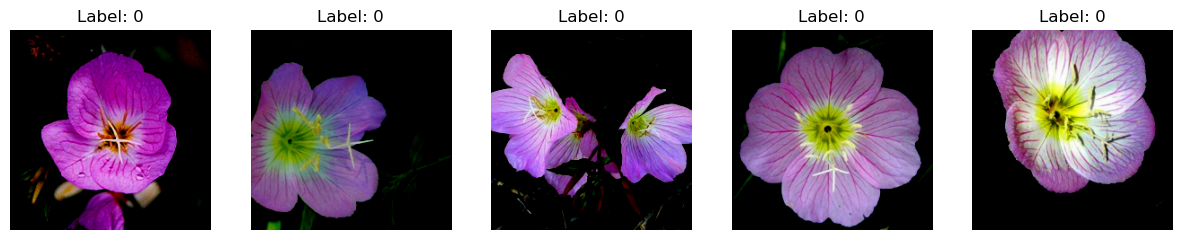

(49, 8, torch.Size([3, 224, 224]), torch.Size([3, 224, 224]), (0, 0, 0, 0, 0))

In [15]:
# 看一眼数据格式
dataiter = iter(trainset)
images, labels = zip(*[next(dataiter) for _ in range(5)])
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    img = images[i].numpy().transpose((1, 2, 0))  # 转换为 HWC 格式
    axes[i].imshow(img)
    axes[i].set_title(f'Label: {labels[i]}')
    axes[i].axis('off')
plt.show()

len(train_loader), len(val_loader), images[0].shape, images[0].shape, labels[:5]

In [16]:
def check_grad(model):
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(f'{name}: {param.grad.abs().mean()}')

def lock_bn(model):
    if isinstance(model, nn.BatchNorm2d):
        model.eval()

# 精度计算函数
def cal_accuracy(model, loader):
    model.eval()
    model.apply(lock_bn)
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss().to(device)
    with torch.no_grad():
        for data, target in tqdm(loader):
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output, 1)
            correct += (predicted == target).sum().item()
            total += target.size(0)
    accuracy = correct/total
    # print("target:", target[:5])
    # print("output:", output[:5])
    # print("predicted:", predicted[:5])
    return accuracy


In [17]:
# 训练
best_model = "./best_model/best_model.pth"
checkpoint = "./checkpoint.pth"
model = resnet(channels=[64, 64, 128, 256, 128]).to(device)
if os.path.exists(checkpoint):
    model.load_state_dict(torch.load(checkpoint, weights_only=True))
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-4)
epochs = 1000
best_acc = 0.5
best_loss = 1e3
# model.train()
writer_path="../tf-logs/log(flower)_new"
writer = SummaryWriter(log_dir=writer_path, flush_secs=60)
# print(summary(model, (3, 224, 224), device="cuda"))
# print(sum(1 for _ in model.modules()) )

In [ ]:
for epoch in range(epochs):
    model.train()
    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch}"):
        correct, total = 0, 0
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)
        
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)
        train_acc = correct/total
        # check_grad(model)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    val_acc = cal_accuracy(model, val_loader)
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model)
        print(f"模型已保存在{best_model}路径下。")
    writer.add_scalar("loss/train", loss.item(), epoch*len(train_loader)+batch_idx)
    writer.add_scalar("acc/train", train_acc, epoch*len(train_loader)+batch_idx)
    writer.add_scalar("acc/val", val_acc, epoch*len(train_loader)+batch_idx)
    print(f"Epoch:{epoch}, loss:{loss.item()}, train_acc:{train_acc}, val_acc:{val_acc}")
    torch.save(model.state_dict(), checkpoint)
    if epoch%50 == 49:
        torch.save(model.state_dict(), checkpoint)
        test_acc = cal_accuracy(model, test_loader)
        writer.add_scalar("acc/test", test_acc, epoch*len(train_loader)+batch_idx)
        print(f"test_acc:{test_acc}")

100%|██████████| 8/8 [00:06<00:00,  1.27it/s]


模型已保存在./best_model/best_model.pth路径下。
Epoch:0, loss:0.7726889252662659, train_acc:0.6, val_acc:0.703921568627451


100%|██████████| 8/8 [00:06<00:00,  1.27it/s]


模型已保存在./best_model/best_model.pth路径下。
Epoch:1, loss:0.7029139399528503, train_acc:0.8, val_acc:0.7137254901960784


100%|██████████| 8/8 [00:06<00:00,  1.29it/s]


...

100%|██████████| 8/8 [00:06<00:00,  1.18it/s]


Epoch:198, loss:0.2400117665529251, train_acc:0.8, val_acc:0.7156862745098039


100%|██████████| 8/8 [00:06<00:00,  1.28it/s]


Epoch:199, loss:0.724990963935852, train_acc:0.8, val_acc:0.7225490196078431


 50%|█████     | 4/8 [00:03<00:03,  1.26it/s]

In [ ]:
# # test
# import cv2
# from PIL import Image

# best_model = "./best_model/best_model.pth"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = resnet(channels=[64, 64, 128, 256, 128]).to(device)
# model.load_state_dict(torch.load(best_model))
# model.eval()

# image1 = './Flowers_102.jpg'
# input_image = cv2.imread(image1)
# input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
# input_image = Image.fromarray(input_image)
# input_tensor = transform(input_image).unsqueeze(0).to(device)
# target_tensor=0

# with torch.no_grad():
#     output_tensor = model(input_tensor)
# loss = criterion(output_tensor, target_tensor)
# print(output_tensor)